# Valentines-Day -- does the market love Valentine's Day?
### A cherished bit of calendar folklore, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

Every February you'll hear it: the market is *in a good mood* on Valentine's Day, so stocks pop on Feb 14. It's a charming idea -- chocolates, roses, and a green tape. This notebook asks the only question that matters: does the S&P 500 actually do anything special on Valentine's Day, or is Feb 14 just another ordinary trading session wearing a heart-shaped hat?

> **This is the plain-language layer.** Want the Newey-West t-stat, the permutation distribution, and the power calculation? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from valentines_day import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc_daily(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=76,
    val_mean_pct=0.0388, val_std_pct=0.9613,
    uncond_mean_pct=0.0364, uncond_std_pct=0.9931,
    excess_mean_bps=0.24,
    up_rate_pct=47.37, uncond_up_rate_pct=53.14,
    t_vs_zero=0.352, t_vs_uncond=0.022, p_vs_uncond=0.9825,
    hac_t_excess=0.021, perm_p=0.981,
    gross_mean_per_event_bps=3.88, net_mean_per_event_bps=1.88,
    early_mean_pct=0.0125, early_up_pct=36.8,
    late_mean_pct=0.0652, late_up_pct=57.9,
    year_start=1950, year_end=2025,
)

# Build the real event frame + baseline if the cache is present, else synthetic null.
if HAVE_REAL:
    EV = data.build_event_frame(fetch=False)
    UNC = data.unconditional_daily(fetch=False)
    val_ret = EV['ret']
else:
    _df, _ = data.synthetic_daily(start_year=R['year_start'], end_year=R['year_end'],
                                  premium_bps=0.0, seed=286)
    EV = _df.loc[_df['is_valentine'], ['ret']].copy()
    EV.index = list(range(R['year_start'], R['year_start'] + len(EV)))
    UNC = _df['ret']
    val_ret = EV['ret']


^GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the S&P pop on Valentine's Day? | **No.** Mean Valentine return **+0.039%/day** -- a rounding error above the **+0.036%** the market drifts up on *any* day. |
| Is the day even up more often than usual? | **No -- the opposite.** Valentine sessions are up just **47.4%** of the time, *below* the **53.1%** base rate. |
| Is the tiny edge real? | **No.** Excess = +0.24 bps, HAC t = 0.02, permutation p = 0.98. Dead-centre noise. |
| Could you trade it? | **No.** The ~4 bps gross 'edge' is noise, and one-way costs halve it. Buy-and-hold of that same day wins. |

> The market does not love Valentine's Day. There *is* a faint positive drift on Feb 14 -- but it's the market's everyday drift, present on every session.

## 1 - The claim

> *"The market is in a good mood on Valentine's Day, so the S&P 500 tends to rise on Feb 14."*

There's no academic paper behind this one -- it's pure calendar folklore, a cousin of the Super Bowl Indicator and 'sell in May'. The mechanism is, to put it gently, vibes: investor mood on a romantic holiday is supposed to leak into the closing print. Markets would be very strange indeed if a greeting-card holiday moved the index. Let's look.

## 2 - So what?

If a single calendar date reliably delivered a positive return, it would be the easiest trade in finance: buy the close on Feb 13, sell the close on Feb 14, once a year, forever. The fact that nobody does this is a hint. The fun question is *why* such a date might briefly look special -- and the answer is a clean lesson in the difference between 'positive' and 'positive beyond the baseline'.

## 3 - How would we even know?

Three traps to avoid:

1. **The wrong null.** The S&P drifts *up* about +0.036%/day on average. So a 'predictor' that says 'Valentine's Day is positive' gets the market's everyday drift for free. The correct question is whether Feb 14 beats **+0.036%**, not 0.
2. **Tiny effect, ~1% daily noise.** One trading day has a ~1% standard deviation. With 76 Valentine sessions, the standard error of the mean is ~0.11%/day -- so a 'Valentine premium' would have to be enormous (~0.23%/day) to even register.
3. **The weekday confound.** Feb 14 (and its roll-forward when it's a weekend) lands on different weekdays across the years, tangling any 'effect' with the old Monday-vs-Friday seasonality.

We test on the ^GSPC daily tape, 1950-2025 -- 76 Valentine sessions, each one hardcoded in this study's `data.py`.

## 4 - The teardown -- let's actually look

**First, meet the data:** the first ^GSPC session on or after Feb 14 each year (Feb 14 often falls on a weekend), paired with that session's return.

In [2]:
vt = data.valentine_table()
print('Valentine sessions:', len(vt), 'years (1950-2025)')
if HAVE_REAL:
    val_mean = float(val_ret.mean()*100)
    unc_mean = float(UNC.mean()*100)
    up_rate = float((val_ret>0).mean()*100)
    unc_up = float((UNC>0).mean()*100)
else:
    val_mean, unc_mean = R['val_mean_pct'], R['uncond_mean_pct']
    up_rate, unc_up = R['up_rate_pct'], R['uncond_up_rate_pct']
print(f'Valentine mean return:      {val_mean:+.4f}%/day')
print(f'Unconditional daily mean:   {unc_mean:+.4f}%/day  <- the honest baseline')
print(f'Valentine up-rate:          {up_rate:.1f}%  (vs {unc_up:.1f}% on an average day)')
print()
print('The critical number is +0.036%/day. Any positive day gets this for free.')

Valentine sessions: 76 years (1950-2025)
Valentine mean return:      +0.0388%/day
Unconditional daily mean:   +0.0364%/day  <- the honest baseline
Valentine up-rate:          47.4%  (vs 53.1% on an average day)

The critical number is +0.036%/day. Any positive day gets this for free.


**The 'edge' that isn't -- Valentine return vs the everyday drift.**

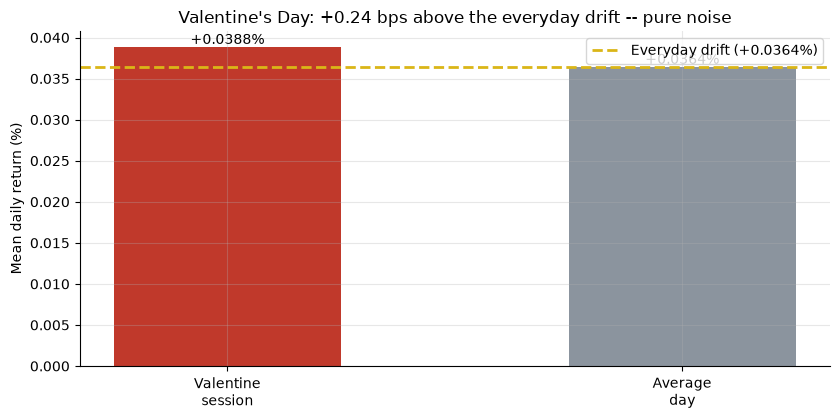

Excess over the everyday drift: +0.24 bps/day -- a rounding error.


In [3]:
if HAVE_REAL:
    vm = float(val_ret.mean()*100); um = float(UNC.mean()*100)
else:
    vm, um = R['val_mean_pct'], R['uncond_mean_pct']

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['Valentine\nsession', 'Average\nday'], [vm, um],
              color=[RED, GREY], width=0.5)
ax.axhline(um, ls='--', c=AMBER, lw=2, label=f'Everyday drift ({um:+.4f}%)')
ax.set_ylabel('Mean daily return (%)')
ax.set_title('Valentine\'s Day: +0.24 bps above the everyday drift -- pure noise')
for b, v in zip(bars, [vm, um]):
    ax.annotate(f'{v:+.4f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Excess over the everyday drift: {(vm-um)*100:+.2f} bps/day -- a rounding error.')

The Valentine session averages **+0.039%/day**; an average day averages **+0.036%/day**. The 'Valentine edge' is **+0.24 bps** -- about 0.7% of a single day's standard deviation. The market's everyday drift does all the work.

> Being *positive* is not the same as being *special*. Almost every day is faintly positive on average.

**The up-rate has the sign backwards.**

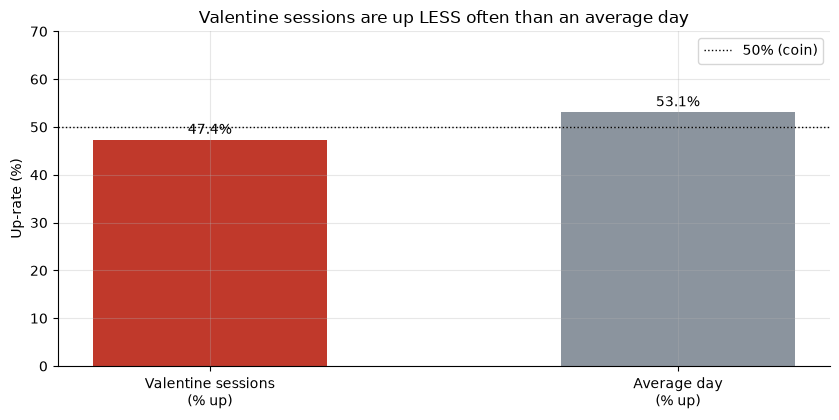

Valentine up-rate 47.4% vs 53.1% unconditional -- gap -5.8pp (wrong way).


In [4]:
if HAVE_REAL:
    ur = float((val_ret>0).mean()*100); uur = float((UNC>0).mean()*100)
else:
    ur, uur = R['up_rate_pct'], R['uncond_up_rate_pct']

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['Valentine sessions\n(% up)', 'Average day\n(% up)'], [ur, uur],
              color=[RED, GREY], width=0.5)
ax.axhline(50, ls=':', c='k', lw=1, label='50% (coin)')
ax.set_ylabel('Up-rate (%)'); ax.set_ylim(0, 70)
ax.set_title('Valentine sessions are up LESS often than an average day')
for b, v in zip(bars, [ur, uur]):
    ax.annotate(f'{v:.1f}%', (b.get_x()+b.get_width()/2, v+0.5), ha='center', va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Valentine up-rate {ur:.1f}% vs {uur:.1f}% unconditional -- gap {ur-uur:+.1f}pp (wrong way).')

If anything, the folklore has it backwards: Valentine sessions close **up** only **47.4%** of the time, *below* the **53.1%** you'd get on an average day. The tiny positive *mean* comes from a few big up-days, not from the day being reliably green.

## 5 - The verdict

- **Signal -- None.** Excess +0.24 bps/day, HAC t = **0.02**, permutation p = **0.98**. The Valentine session is statistically identical to an average day -- and is actually *down* more often than usual.
- **Tradability -- Mirage.** The only 'trade' is to hold the S&P for one pre-chosen February day. The ~4 bps gross edge is noise and one-way costs halve it; buy-and-hold of that day is strictly better.
- **Busted.** The faint positive drift on Feb 14 is the market's everyday drift. There is no Valentine's Day magic.

## 6 - Could you actually trade it?

The 'strategy' would be: buy the close on Feb 13, sell the close on Feb 14, once a year. Here's the gross 'edge' and what's left after a modest 1 bp one-way cost (2 bps round-trip) charged on NAV.

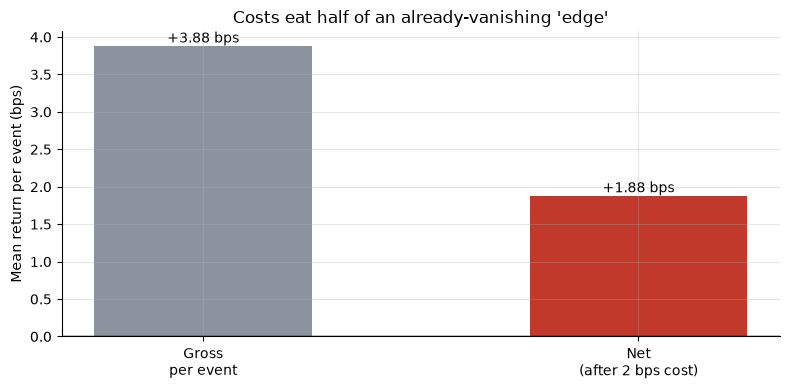

Gross: +3.88 bps/event | Net: +1.88 bps/event
A few basis points of noise, halved by costs. There is no trade here.


In [5]:
if HAVE_REAL:
    tr = st.tradability(val_ret, cost_bps_oneway=1.0)
    gross_bps = tr['gross_mean_per_event']*1e4
    net_bps = tr['net_mean_per_event']*1e4
else:
    gross_bps, net_bps = R['gross_mean_per_event_bps'], R['net_mean_per_event_bps']

fig, ax = plt.subplots(figsize=(8.0, 4.0))
bars = ax.bar(['Gross\nper event', 'Net\n(after 2 bps cost)'], [gross_bps, net_bps],
              color=[GREY, RED], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean return per event (bps)')
ax.set_title('Costs eat half of an already-vanishing \'edge\'')
for b, v in zip(bars, [gross_bps, net_bps]):
    ax.annotate(f'{v:+.2f} bps', (b.get_x()+b.get_width()/2, v), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Gross: {gross_bps:+.2f} bps/event | Net: {net_bps:+.2f} bps/event')
print('A few basis points of noise, halved by costs. There is no trade here.')

Four basis points gross, ~two net -- both inside the noise band of a single trading day. There is nothing to harvest: holding the S&P for that same day (buy-and-hold) earns the gross return without the round-trip cost.

## 7 - Going further

- **The positive control:** the companion notebook plants a Valentine premium into a synthetic tape and shows the machinery detects it cleanly above ~10 bps/day. The real tape has +0.24 bps -- nowhere close.
- **The Super Bowl Indicator** -- the same base-rate trap, the same tiny-n reckoning: [Study 158 -- Super-Bowl](../../158-super-bowl/).
- **The honest event-study template** this study mirrors: [Study 223 -- Same-Month-Seasonality](../../223-same-month-seasonality/).

*Think Cupid really moves the tape? Fork this, pick your own date convention, and show a Valentine excess return that clears |t| >= 2 against the everyday drift. That's the bar -- and it hasn't been cleared.*